# Guild or Functional Richness Analysis

Requires a species-to-guild mapping file. Notebook auto-checks for mapping and proceeds if found.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='paper')
RANDOM_SEED = 42


In [9]:
mapping_candidates = [
    Path('species_guild_mapping.csv'),
    Path('stateProvince/species_guild_mapping.csv'),
    Path('../species_guild_mapping.csv')
]

# Prefer a mapping file next to this notebook.
default_map_path = Path('species_guild_mapping.csv')

map_path = next((m for m in mapping_candidates if m.exists()), None)
if map_path is None:
    p = next((x for x in [Path('file6.csv'), Path('../file6.csv'), Path('../../file6.csv')] if x.exists()), None)
    species = (
        pd.read_csv(p, usecols=['verbatimScientificName'], low_memory=False)['verbatimScientificName']
        .dropna()
        .astype(str)
        .str.strip()
    )
    species = species[species != ''].drop_duplicates().sort_values()
    template = pd.DataFrame({'verbatimScientificName': species, 'guild': 'Unknown'})

    default_map_path.parent.mkdir(parents=True, exist_ok=True)
    template.to_csv(default_map_path, index=False)
    map_path = default_map_path

    print(f'No mapping file found. Created template at: {map_path.resolve()}')
    print('All species are currently set to guild=Unknown. Edit the CSV with real guilds, then rerun.')
else:
    print('Using mapping:', map_path.resolve())


No mapping file found. Created template at: /home/ekeke/Projects/DataScience/bird_diversity_project/stateProvince/species_guild_mapping.csv
All species are currently set to guild=Unknown. Edit the CSV with real guilds, then rerun.


Mapped to known guilds: 89.3% of thinned records


,stateProvince,mean_guild_richness,n_cells
4,Colombo,8.076923,39
6,Gampaha,7.647059,68
16,Matara,7.228070,57
7,Hambantota,7.202247,89
21,Puttalam,7.069307,101
14,Mannar,7.020000,50
9,Kalutara,7.012500,80
15,Matale,6.970588,68
5,Galle,6.800000,70
1,Anuradhapura,6.750000,124


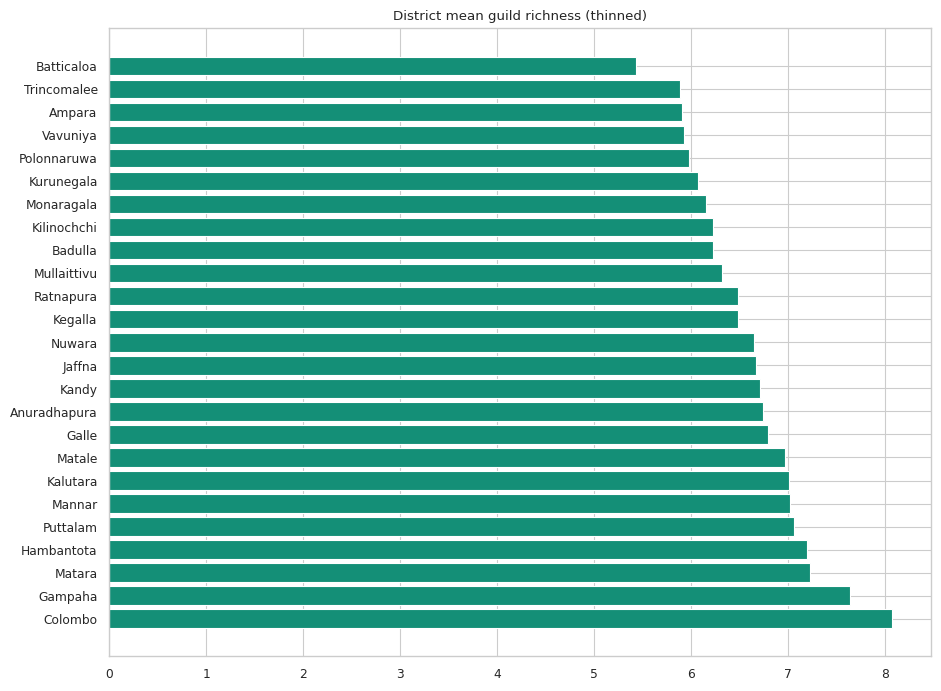

In [13]:
if map_path is not None:
    p = next((x for x in [Path('file6.csv'), Path('../file6.csv'), Path('../../file6.csv')] if x.exists()), None)
    cols = ['stateProvince','verbatimScientificName','decimalLatitude','decimalLongitude','eventDate']
    df = pd.read_csv(p, usecols=cols, low_memory=False).dropna(subset=cols)
    for c in ['decimalLatitude','decimalLongitude']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['decimalLatitude','decimalLongitude'])
    lon0 = float(df['decimalLongitude'].median())
    lat0 = float(df['decimalLatitude'].median())
    lat_rad = np.radians(df['decimalLatitude'].to_numpy())
    df['x_km'] = (df['decimalLongitude'].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
    df['y_km'] = (df['decimalLatitude'].to_numpy() - lat0) * 110.574
    df['grid_x'] = np.floor(df['x_km']/5.0).astype(int)
    df['grid_y'] = np.floor(df['y_km']/5.0).astype(int)
    df['cell_id'] = df['stateProvince'].astype(str) + '|' + df['grid_x'].astype(str) + '_' + df['grid_y'].astype(str)
    df['_key'] = df['cell_id'] + '|' + df['verbatimScientificName']
    rng = np.random.default_rng(RANDOM_SEED)
    df['_r'] = rng.random(len(df))
    thin = df.sort_values('_r').groupby('_key', as_index=False).head(1)

    mapping = pd.read_csv(map_path)
    mapping['verbatimScientificName'] = mapping['verbatimScientificName'].astype(str).str.strip()
    thin['verbatimScientificName'] = thin['verbatimScientificName'].astype(str).str.strip()

    joined = thin.merge(mapping[['verbatimScientificName','guild']], on='verbatimScientificName', how='left')
    joined['guild'] = joined['guild'].fillna('Unknown').astype(str).str.strip()
    joined.loc[joined['guild'] == '', 'guild'] = 'Unknown'

    known_share = (joined['guild'] != 'Unknown').mean() * 100
    print(f'Mapped to known guilds: {known_share:.1f}% of thinned records')

    if known_share == 0:
        print('No real guild labels found yet, so plotting is skipped to avoid a misleading all-1.0 chart.')
        print(f'Fill real guild labels in: {map_path.resolve()} and rerun this cell.')
        todo = mapping.copy()
        todo['guild'] = todo['guild'].fillna('Unknown').astype(str)
        todo = todo[todo['guild'].str.strip().eq('Unknown')]
        print(f'Species still needing guild labels: {len(todo)}')
        display(todo.head(30))
    else:
        guild_cell = joined.groupby(['stateProvince','cell_id'], as_index=False).agg(guild_richness=('guild','nunique'))
        guild_dist = guild_cell.groupby('stateProvince', as_index=False).agg(mean_guild_richness=('guild_richness','mean'), n_cells=('cell_id','count')).sort_values('mean_guild_richness', ascending=False)

        display(guild_dist.head(20))

        plt.figure(figsize=(9.5, max(5,0.28*len(guild_dist))))
        plt.barh(guild_dist['stateProvince'], guild_dist['mean_guild_richness'], color='#148f77')
        plt.title('District mean guild richness (thinned)')
        plt.tight_layout()
        plt.show()
